# Taller 5 — Mini proyecto: crear un ChatGPT propio usando un RAG

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yeavil-neny/NLP-ProcesamientoLeguajeNatural/blob/main/Taller_5/proyecto_rag_chatbot_recetas.ipynb)
## Caso propio: asistente culinario conversacional sobre el corpus de recetas hispanoamericanas `RecetasDeLaAbuela`

Este notebook se implementa, con un caso nuevo, un chatbot con **Retrieval Augmented Generation (RAG)** en la línea de los dos notebooks guía de la sesión (técnica a mano y LangChain), pero con un corpus completamente distinto: **las recetas de cocina hispanoamericanas del dataset [somosnlp/RecetasDeLaAbuela](https://huggingface.co/datasets/somosnlp/RecetasDeLaAbuela)** (20.236 recetas web de páginas de cocina de México, Colombia, Perú y otros países, con título, URL original, ingredientes y pasos).

### 0.1 El problema que se aborda y su justificación

Aunque un modelo generativo como Llama 3 es un interlocutor notable, identificamos tres limitantes críticas cuando requerimos información factual y verificable:

* Conocimiento estático: El modelo se limita a la información procesada durante su entrenamiento. Los datos posteriores a esa fecha le resultan invisibles y actualizar su base de conocimiento requeriría un reentrenamiento, un proceso costoso e inviable para la escala de nuestro proyecto.

* Riesgo de alucinación: Ante consultas sobre datos que no domina, el modelo carece de mecanismos para reconocer su falta de información, lo que lo lleva a fabricar respuestas verosímiles pero falsas.

* Nula trazabilidad: Las respuestas provienen exclusivamente de la memoria de parámetros del modelo, lo que nos impide rastrear o enlazar la información a una fuente documental.

Observamos estas limitantes de forma directa en el dominio culinario que seleccionamos: si el modelo inventa una receta, podría sugerir cantidades incorrectas de ingredientes o tiempos de horneo erróneos, haciendo imposible su auditoría.

Nuestra propuesta de proyecto invierte este problema: en lugar de depender de la memoria interna del modelo, construimos una memoria externa citable conformada por el corpus de recetas. De este modo, configuramos al modelo para que sus respuestas estén condicionadas estrictamente a los documentos recuperados, obligándolo a citar la receta y su página web de origen. Este enfoque materializa la motivación expuesta por Lewis et al. (2020): desacoplar los parámetros de generación de los parámetros de almacenamiento de conocimiento, logrando así un sistema interactivo y completamente trazable.

*En este notebook no se entrena ningún modelo: se combinan componentes pre-entrenados (un encoder de embeddings y un LLM servido con Ollama) en la arquitectura clásica de un RAG.*

### 0.2 Contenido de la notebook

1. Arquitectura del sistema
2. El dataset y su exploración (EDA)
3. Curación del corpus
4. Chunking: documento entero o fragmentos (decisión con experimento)
5. Vector store y recuperador (`DocumentRetriever`)
6. Evaluación del recuperador: E-R1 (chunking), E-R2 (encoder), E-R3 (k)
7. El LLM (Llama 3 vía Ollama) y el chatbot RAG con citas
8. Comparación: respuesta con RAG frente a respuesta sin RAG
9. Comparativa con LangChain sobre el mismo corpus y técnica preferida
10. Interfaz conversacional con Gradio
11. Conclusiones

### 0.3 Referencias

- Lewis et al., *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks*: [arxiv.org/abs/2005.11401](http://arxiv.org/abs/2005.11401)
- Tunstall, von Werra y Wolf, *Natural Language Processing with Transformers* (O'Reilly, 2022)
- Notebooks guía de la sesión 5 (`1-ollama-rag.ipynb` y `2-ollama-langchain.ipynb`) y sus versiones comentadas en este repositorio
- Wang et al., *Multilingual E5 Text Embeddings*: [arxiv.org/abs/2402.05672](https://arxiv.org/abs/2402.05672)

## 1. Arquitectura del sistema

El flujo del RAG construido aquí replica la cadena clásica (Lewis et al., 2020) adaptada a un LLM pre-entrenado que no se puede re-entrenar: el retriever (NR) y el generator (NG) operan por separado y se conectan por texto.

```text
                pregunta del usuario
                        |
        [1] REFORMULADOR (solo si hay historial)
            Llama 3 reescribe la pregunta como una
            consulta autónoma, con la ayuda del historial
                        |
        [2] ENCODER (multilingual-e5)
            pregunta -> vector de 1024 dimensiones
                        |
        [3] RETRIEVER (producto punto + top-k)
            busca en la matriz de embeddings del corpus
            los k fragmentos más parecidos
                        |
        [4] GENERADOR (Llama 3 servido con Ollama)
            prompt = instrucciones + contexto (texto de
            los fragmetos recuperados) + pregunta
                        |
        [5] SALIDA: respuesta natural + citas
            (título, país y URL de cada receta usada)
```

**Por qué es una solución adecuada para el problema.** Cada bloque separa una responsabilidad: la memoria del dominio (el corpus y su indexación) es actualizable sin tocar el modelo; la recuperación es auditable (se puede ver qué documentos se usaron y con qué puntaje); y la generación es trazable (la respuesta llega con las citas). Frente a la alternativa de afinar (fine tuning) Llama 3 con recetas, que reentrenaría 8 mil millones de parámetros, aquí el costo de agregar, corregir o eliminar recetas es un re-cálculo de embeddings parcial, medido en minutos en Colab.

## 2. Configuración del entorno

Como en los notebooks guía, la celda siguiente detecta el entorno de ejecución e instala las librerías necesarias. Para la corrida en **Colab con GPU T4**, tal como queda documentado en los outputs de esta versión: las librerías se instalan con `pip` en la celda siguiente; Ollama se instala con el script oficial en la celda de la sección 9 (`apt install zstd` + `curl -fsSL https://ollama.com/install.sh | sh`); el servicio se lanza en la terminal de Colab (mediante `%load_ext colabxterm` y `%xterm`, o la terminal propia de Colab) con `ollama serve &`; y el modelo se descarga con `!ollama pull llama3` (unos 4.7 GB, solo la primera vez). En un computador propio con Ollama instalado y su servicio en marcha, no hacen falta esas celdas.

In [1]:
import warnings

warnings.filterwarnings('ignore')

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print('¿Ejecutando en Google Colab?', IN_COLAB)


¿Ejecutando en Google Colab? True


In [2]:
# Librerías: datasets (carga del corpus), sentence-transformers (encoder de
# embeddings), gradio (interfaz), wordcloud (nubes de palabras del EDA),
# ollama (cliente del LLM), faiss-cpu (comparativa LangChain) y los
# conectores de LangChain. En Colab se instalan; en local se asume que ya
# están disponibles.
!test '{IN_COLAB}' = 'True' && pip install -q datasets sentence-transformers gradio wordcloud ollama faiss-cpu langchain-ollama langchain-community langchain-huggingface colab-xterm


## 3. El dataset: `RecetasDeLaAbuela`

El corpus elegido es el del SomosNLP (Hackathon #Somos600M, 2024), la mayor colección pública de recetas en español. Difiere del corpus de los guías (Wikihow) tanto en dominio como en forma: cada documento es corto y está estructurado en campos (ingredientes, pasos, país, duración), lo que condiciona el chunking y las citas. Se usa la configuración `version_1` del dataset, la que corrige y ordena el CSV original.

In [3]:
from datasets import get_dataset_config_names, load_dataset

# Descubre las configuraciones disponibles del dataset y las imprime:
# cada configuración es una 'versión' distinta del CSV.
configs = get_dataset_config_names('somosnlp/RecetasDeLaAbuela')
print('Configuraciones:', configs)

# Se carga la versión curada 'version_1' (20.236 filas, 14 columnas).
dataset = load_dataset('somosnlp/RecetasDeLaAbuela', 'version_1', split='train')
dataset


Configuraciones: ['version_inicial', 'version_1']


main.csv: reconstructing file:   0%|          |  0.00B / 40.3MB            

main.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/20236 [00:00<?, ? examples/s]

Dataset({
    features: ['Id', 'Nombre', 'URL', 'Ingredientes', 'Pasos', 'Pais', 'Duracion', 'Categoria', 'Contexto', 'Valoracion y Votos', 'Comensales', 'Tiempo', 'Dificultad', 'Valor nutricional'],
    num_rows: 20236
})

In [4]:
# renombrar columnas a snake_case para manipulación cómoda
import pandas as pd

pd.set_option('display.max_colwidth', 60)

dataset = dataset.rename_columns({
    'Id': 'id', 'Nombre': 'nombre', 'URL': 'url', 'Ingredientes': 'ingredientes',
    'Pasos': 'pasos', 'Pais': 'pais', 'Duracion': 'duracion', 'Categoria': 'categoria',
    'Comensales': 'comensales', 'Dificultad': 'dificultad',
})

# Se conservan solo las columnas relevantes para el RAG: identificación y
# cita (id, nombre, url), el contenido (ingredientes, pasos) y metadatos
# útiles para el EDA y para las citas (pais, duracion, comensales, categoria).
KEEP = ['id', 'nombre', 'url', 'ingredientes', 'pasos', 'pais', 'duracion', 'categoria', 'comensales', 'dificultad']
dataset = dataset.remove_columns([c for c in dataset.column_names if c not in KEEP])

dataset.set_format(type='pandas')
df_raw = dataset.to_pandas()
df_raw.head(10)


,id,nombre,url,ingredientes,pasos,pais,duracion,categoria,comensales,dificultad
0,1,Tacos Dorados de Papa,https://www.mexicoenmicocina.com/tacos-dorados-de-papa/,"½ taza de cilantro finamente picado, 1 taza de tomate pi...",Pon las papas enteras en una olla mediana y cúbrelas con...,MEX,01:00,vegetarianos,6,None
1,2,Ensalada de Chayotes,https://www.mexicoenmicocina.com/receta-ensalada-de-chay...,"½ cucharadita sal, ¼ cucharadita de pimienta recién moli...",Coloca los chayotes en una cacerola y cúbralos con agua;...,MEX,00:25,vegetarianos,4,None
2,3,Huevos a la Mexicana,https://www.mexicoenmicocina.com/huevos-a-la-mexicana/,"½ Chile Serrano cortado en pequeños trocitos*, 2 huevos ...",Calienta el aceite en una sartén mediana a fuego medio-a...,MEX,00:15,vegetarianos,1,None
3,4,Rajas de Chile Poblano con Crema,https://www.mexicoenmicocina.com/rajas-de-chile-poblano-...,"½ cucharadita Sal, 2 cucharadas de aceite vegetal, 1 ceb...",Para asar los chiles:Colocas los chiles ya limpios direc...,MEX,00:30,vegetarianos,None,None
4,5,Papas a la Mexicana,https://www.mexicoenmicocina.com/papas-a-la-mexicana/,"⅓ taza de cebolla blanca en cubitos, Sal al gusto., 6 To...",Calienta el aceite vegetal en una sartén grande a fuego ...,MEX,00:25,vegetarianos,None,None
5,6,Nopalitos navegantes,https://www.mexicoenmicocina.com/nopalitos-navegantes/,"4 huevos, Sal y pimienta al gusto., 3 Nopales grandes co...",Llena una cacerola de tamaño mediano con agua y colócala...,MEX,00:30,vegetarianos,4,None
6,7,Guacamole Casero,https://www.mexicoenmicocina.com/guacamole-casero/,"1 chile serrano, 4-5 Ramitas de Cilantro, Sal al gusto, ...",Corta la cebolla y el Chile Serrano (si no quieres que s...,MEX,00:20,vegetarianos,1,None
7,8,Calabacitas al vapor,https://www.mexicoenmicocina.com/calabacitas-al-vapor/,2 calabazas de tamaño mediano o calabacín cortada en rod...,Coloca la calabaza en rodajas en una sartén de tamaño me...,MEX,00:15,vegetarianos,4,None
8,9,Sopa de Calabacitas con Elote,https://www.mexicoenmicocina.com/sopa-de-calabacitas-con...,"1 Diente de ajo pequeño picado, 1 Caldo de Pollo Knorr -...",Sirva en cuencos y decorar con queso fresco desmenuzado ...,MEX,00:30,vegetarianos,2,None
9,10,Pasta con salsa cremosa de chile poblano,https://www.mexicoenmicocina.com/pasta-con-salsa-cremosa/,"1 diente de ajo grande o 2 pequeños, ½ taza de leche, 2 ...","Mientras preparamos la salsa, cocina la pasta de acuerdo...",MEX,00:30,vegetarianos,4,None


## 4. EDA — exploración del corpus

Antes de construir el RAG se responde a tres preguntas que condicionan el diseño: ¿está completo el corpus?, ¿los documentos son tan largos que exigen partition (chunking)?, y ¿qué cobertura temática tiene una pregunta típica?

In [5]:
# Valores nulos por columna y conteos generales del dataset crudo.
nulls = df_raw.isnull().sum()
print('Recetas crudas:', len(df_raw))
print('\nNulos por columna:')
for col, n in nulls.items():
    print(f'  {col:<12} {n:>6} ({n / len(df_raw):.1%})')
print('\nPaíses únicos:', df_raw.pais.nunique(), '| URLs únicas:', df_raw.url.nunique())


Recetas crudas: 20236

Nulos por columna:
  id                0 (0.0%)
  nombre            0 (0.0%)
  url               0 (0.0%)
  ingredientes      0 (0.0%)
  pasos             0 (0.0%)
  pais           5591 (27.6%)
  duracion       6630 (32.8%)
  categoria      6748 (33.3%)
  comensales     6627 (32.7%)
  dificultad     6454 (31.9%)

Países únicos: 20 | URLs únicas: 19369


**Observación (corrida real).** Los campos sustanciales del corpus están completos: `id`, `nombre`, `url`, `ingredientes` y `pasos` no presentan nulos (0.0% en los cinco). Los nulos se concentran en los metadatos descriptivos: `pais` (27.6%), `duracion` (32.8%), `categoria` (33.3%), `comensales` (32.7%) y `dificultad` (31.9%). Hay 20 países distintos, pero solo 19.369 URLs únicas sobre 20.236 recetas: unas 867 recetas comparten URL con otra (4.3%), señal de raspados duplicados que la curación debe retirar. Dos consecuencias de diseño: los filtros de curación no pueden exigir metadatos (harían perder un tercio del corpus), y algunas citas del chatbot se verán sin país (`None`) porque el dato no existe en la fuente.

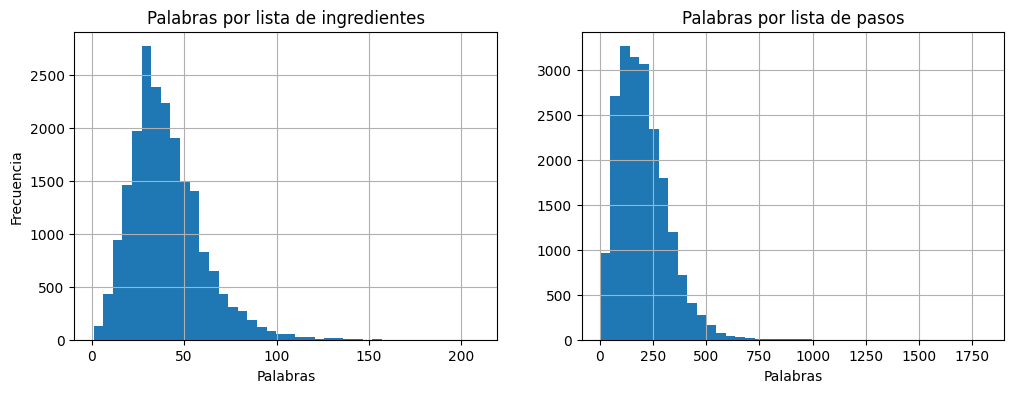

,n_ing,n_pasos
count,20236.0,20236.0
mean,40.5,204.4
std,19.9,118.4
min,1.0,6.0
25%,27.0,116.0
50%,38.0,187.0
75%,51.0,270.0
max,209.0,1810.0


In [6]:
# --- 4.1 Longitud de los documentos ---
# Histograma del número de palabras de Ingredientes y Pasos. Define si el
# corpus necesita chunking: si cada documento cabe en el contexto del LLM,
# la partición puede ser innecesaria (o incluso dañina, al cortar el
# procedimiento de una receta en dos).
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df_raw.ingredientes.dropna().apply(lambda t: len(t.split())).hist(ax=ax[0], bins=40)
df_raw.pasos.dropna().apply(lambda t: len(t.split())).hist(ax=ax[1], bins=40)
ax[0].set_title('Palabras por lista de ingredientes')
ax[0].set_xlabel('Palabras'); ax[0].set_ylabel('Frecuencia')
ax[1].set_title('Palabras por lista de pasos')
ax[1].set_xlabel('Palabras')
plt.show()

# Estadísticas de resumen.
leng = df_raw.assign(n_ing=df_raw.ingredientes.dropna().apply(lambda t: len(t.split())),
                     n_pasos=df_raw.pasos.dropna().apply(lambda t: len(t.split())))
leng[['n_ing', 'n_pasos']].describe().round(1)


**Observación (corrida real).** La lista de ingredientes promedio tiene 40.5 palabras (desviación estándar 19.9; mínimo 1, máximo 209) y los pasos, 204.4 (desviación 118.4; mediana 187; p75 = 270; máximo 1.810). Una receta completa, con su título, ocupa de forma típica unas 250 palabras, muy por debajo del límite de contexto de Llama 3; incluso la receta más larga cabe de sobra. Esto desmonta el argumento del tamaño como justificación a priori del chunking y deja la decisión en manos del experimento de recuperación (E-R1). Además, los mínimos (1 palabra de ingredientes, 6 de pasos) y la cola derecha de los histogramas confirman que existen esqueletos de raspado que la curación descartará.

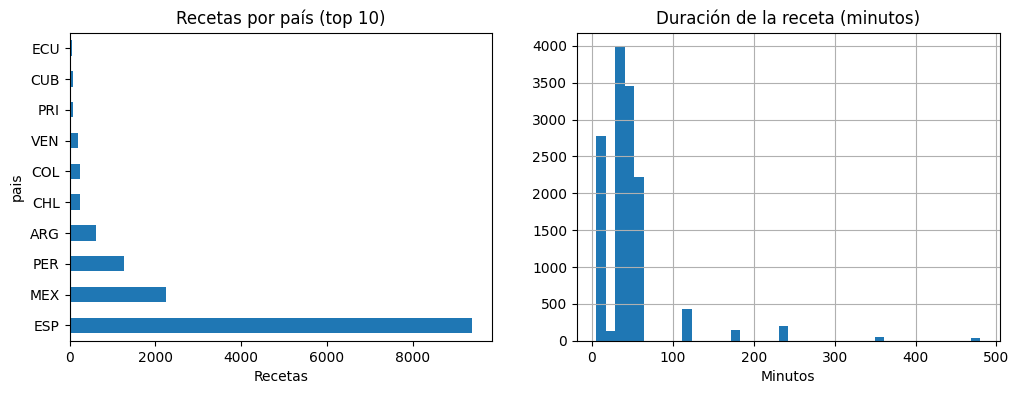

Duración: p50 = 30.0 min | p90 = 60.0 min | máx = 480.0 min


In [7]:
# --- 4.2 Distribución por país y por duración ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
(df_raw.pais.value_counts().head(10)).plot.barh(ax=ax[0])
ax[0].set_title('Recetas por país (top 10)')
ax[0].set_xlabel('Recetas')

minutos = df_raw.duracion.dropna().str.split(':').apply(lambda p: int(p[0]) * 60 + int(p[1]) if len(p) == 2 else None).dropna()
minutos.hist(ax=ax[1], bins=40)
ax[1].set_title('Duración de la receta (minutos)')
ax[1].set_xlabel('Minutos')
plt.show()

print('Duración: p50 =', minutos.median(), 'min | p90 =', minutos.quantile(0.9), 'min | máx =', minutos.max(), 'min')


**Observación (corrida real, lectura de las figuras).** El corpus está desequilibrado por país: España domina con cerca de 9.500 recetas, seguida de México (cerca de 2.200) y Perú (cerca de 1.200); Argentina, Chile, Colombia, Venezuela, Puerto Rico, Cuba y Ecuador completan el top 10 con cientos o decenas de recetas. La consecuencia práctica es que muchas citas del chatbot provienen de sitios de recetas españoles, aunque la consulta pretenda platos latinoamericanos; y 5.591 recetas (27.6%) no declaran país. En duración, la distribución está concentrada: mediana 30 minutos, p90 60 minutos y cola hasta 480 (8 horas); la mayoría de las recetas del corpus son preparaciones caseras de 15 a 60 minutos.

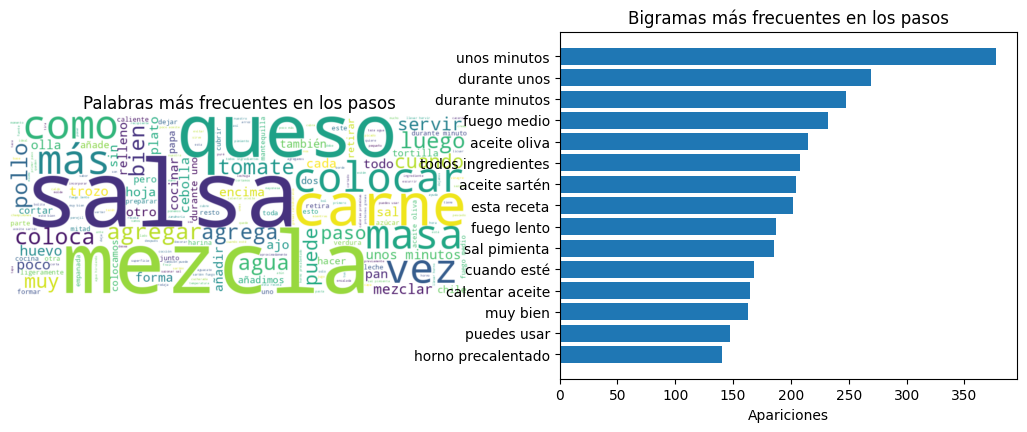

In [8]:
# --- 4.3 Léxico del corpus: nube de palabras y bigramas más frecuentes ---
from collections import Counter
from wordcloud import WordCloud

STOP = {'de', 'la', 'el', 'y', 'en', 'a', 'con', 'los', 'las', 'una', 'un',
        'se', 'del', 'por', 'para', 'que', 'al', 'o', 'sobre', 'hasta',
        'hasta', 'añada', 'agregue'}

def filtrar(text):
    return ' '.join(w for w in text.lower().split() if w not in STOP and w.isalpha() and len(w) > 2)

# Nube de palabras con el texto de los pasos (muestra de 2000 recetas),
# después de filtrar las palabras muy comunes del español.
muestra_pasos = df_raw.pasos.dropna().head(2000).apply(filtrar)
nuvem = WordCloud(width=900, height=350, background_color='white').generate(' '.join(muestra_pasos))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].imshow(nuvem, interpolation='bilinear')
ax[0].axis('off'); ax[0].set_title('Palabras más frecuentes en los pasos')

# Bigramas más frecuentes en los pasos (muestra de 2000 recetas).
bigramas = Counter()
for texto in muestra_pasos:
    palabras = texto.split()
    bigramas.update(zip(palabras, palabras[1:]))
top = bigramas.most_common(15)[::-1]
ax[1].barh([f'{a} {b}' for (a, b), _ in top], [c for _, c in top])
ax[1].set_title('Bigramas más frecuentes en los pasos')
ax[1].set_xlabel('Apariciones')
plt.show()


**Observación (corrida real, lectura de la figura).** El léxico confirma un corpus de procedimiento: dominan en la nube palabras operativas de cocina (`queso`, `salsa`, `mezclar`, `colocar`, `masa`, `carne`, `pollo`, `tomate`). Los bigramas más frecuentes son fórmulas del género receta: `unos minutos` (cerca de 370 apariciones), `durante unos`, `durante minutos`, `fuego medio`, `aceite oliva`, `ingredientes`, `sartén`, `fuego lento`, `sal pimienta`, `calentar aceite` e `horno precalentado`. Implicación para el RAG: el vocabulario genérico del cocinar es frecuente y no discrimina platos, de modo que la señal distintiva de cada receta recae en el título y en los ingredientes específicos; es una razón adicional para que el documento indexado comience por el título.

## 5. Curación del corpus

Con la evidencia del EDA se aplica una limpieza mínima y determinista:

1. **Registros vacíos**: se descartan las filas sin nombre, URL o pasos, y las con URL no válida.
2. **Duplicados**: se eliminan las recetas con la misma URL (misma receta raspada dos veces).
3. **Longitud mínima**: se eliminan las recetas con menos de 25 palabras (imposible cocinar con tan poco) y sin ingredientes.
4. **Documento para el índice**: se construye el texto del documento como título + ingredientes + pasos, el orden que hace que el título (que es lo que una persona escribiría como pregunta) esté presente, y el procedimiento completo a disposición del retriever.

In [9]:
# Curación: filtros + campo 'text' (documento completo) para el índice.
def curar(df):
    vacios = df.nombre.isna() | df.url.isna() | df.pasos.isna()
    df = df[~vacios].copy()
    # URLs válidas y deduplicación exacta sobre la URL.
    df = df[df.url.str.startswith('http')]
    df = df.drop_duplicates(subset='url')
    # Longitud mínima del procedimiento, para no indexar esqueletos
    # (recetas incompletas o plantillas vacías del web scraping).
    n_pasos = df.pasos.apply(lambda t: len(t.split()))
    df = df[n_pasos >= 25]
    # Documento para el índice: título + ingredientes + pasos.
    df['text'] = df.apply(
        lambda r: f"{r.nombre}\n\nIngredientes: {r.ingredientes or ''}\n\nPasos: {r.pasos}",
        axis=1,
    )
    return df

df = curar(df_raw)
print(f'Recetas después de la curación: {len(df)} '
      f'(de {len(df_raw)} crudas, {len(df_raw) - len(df)} eliminadas)')

# Reconstrucción del dataset de Hugging Face con el corpus curado.
from datasets import Dataset
documents_full = Dataset.from_pandas(df.reset_index(drop=True))
documents_full


Recetas después de la curación: 19249 (de 20236 crudas, 987 eliminadas)


Dataset({
    features: ['id', 'nombre', 'url', 'ingredientes', 'pasos', 'pais', 'duracion', 'categoria', 'comensales', 'dificultad', 'text'],
    num_rows: 19249
})

**Observación (corrida real).** La curación deja 19.249 recetas de las 20.236 crudas: 987 eliminadas (4.9%). El recorte es coherente con el EDA: como los campos sustanciales no tienen nulos, el grueso de la baja son las 867 URLs duplicadas (la misma receta raspada dos veces, retiradas por el filtro de deduplicación) y las restantes son recetas cuyo procedimiento quedó por debajo del umbral de 25 palabras (plantillas o esqueletos del web scraping). El campo `text` del documento queda conformado por título + ingredientes + pasos para las 19.249 recetas retenidas, en el orden que prioriza la señal discriminante del título.

## 6. ¿Partir en chunks o indexar la receta completa? (decisión experimentada)

A diferencia de los notebooks de referencia, donde requeríamos particiones (chunks) porque los documentos de Wikihow superaban el límite de contexto, u omitimos explícitamente el particionado para que FAISS indexara los textos enteros, en nuestro corpus de recetas abordamos esta decisión de forma estrictamente empírica. Dado que la receta promedio cabe holgadamente en la ventana de contexto, descartamos el argumento del tamaño; nuestro objetivo se centra exclusivamente en optimizar la calidad de la recuperación.

Para definir la estrategia, planteamos dos hipótesis contrastantes:

* A favor del particionado (chunking): Consideramos que las primeras 100-200 palabras de una receta (ingredientes y pasos iniciales) son suficientes para caracterizar el plato. Esto genera un documento más corto y un vector de un solo tema, lo que reduce el "ruido" de similitud.

* A favor del documento completo: Postulamos que el vector de la receta íntegra captura un retrato más fiel de la preparación, permitiendo recuperar el documento sin depender exclusivamente de los ingredientes iniciales.

Evaluamos esta disyuntiva experimentalmente en la sección 8 mediante métricas de recuperación (hit@k y MRR) aplicadas a un conjunto de preguntas de verificación. De esta manera, garantizamos que nuestra decisión arquitectónica se fundamente en la evidencia de los datos y no en la intuición.

## 7. Vector store y recuperador (`DocumentRetriever`)

Siguiendo la técnica manual del primer notebook, estructuramos el vector store como una matriz de NumPy, asignando una fila por documento y una columna por cada dimensión del embedding. Para el encoder seleccionamos el modelo Multilingual E5 (intfloat/multilingual-e5-large), el mismo utilizado en los notebooks de guía, aunque introdujimos dos diferencias técnicas fundamentales para nuestro caso de uso:

* Uso de prefijos recomendados por el modelo: Dado que E5 fue entrenado anteponiendo la etiqueta query:  a las preguntas y passage:  a los documentos, adoptamos estrictamente esta convención para maximizar la calidad de las similitudes recuperadas.

* Indexación del corpus completo curado (en lugar de una muestra de 5000): Al comprobar que los textos de las recetas son en su mayoría cortos, determinamos que indexar el corpus entero es completamente viable en nuestro entorno de ejecución (Colab). Esto nos permite configurar el sistema RAG con su máxima capacidad de cobertura.

Dado que la indexación es un proceso computacionalmente costoso, lo ejecutamos una única vez: guardamos los embeddings resultantes en la ruta data/vectorstore.npy de manera que, en ejecuciones sucesivas, simplemente cargamos el archivo de forma directa para optimizar los tiempos de respuesta.

In [ ]:
# --- Construcción del vector store (a mano, como el notebook 1) ---
import os
from pathlib import Path
import numpy as np
from sentence_transformers import SentenceTransformer

# Encoder: 'large' (0.56B parámetros, 1024 dim.); en la sección 8.3 se
# compara con 'small' (0.12B, 384 dim.). Se puede cambiar por la 'small'
# en corridas sin GPU.
model_ckpt = 'intfloat/multilingual-e5-large'
embeddings_path = Path('data/vectorstore.npy')

# En Colab (GPU) se indexa el corpus completo; si no hay GPU disponible,
# bajar este límite (por ejemplo, limit = 5000) para acelerar.
limit = 0  # 0 = usar todo el corpus curado
corpus = documents_full if not limit else documents_full.take(limit)

model = SentenceTransformer(model_ckpt)

if embeddings_path.exists():
    vectorstore = np.load(str(embeddings_path))
else:
    # Prefijo 'passage: ' recomendado por E5 para los documentos.
    vectorstore = corpus.map(
        lambda example: {'embedding': model.encode('passage: ' + example['text'])},
        remove_columns=corpus.column_names,
    )
    vectorstore.reset_format()
    vectorstore = np.concatenate(
        [np.array(v['embedding'], dtype=np.float32).reshape(1, -1) for v in vectorstore.to_iterable_dataset()],
        axis=0,
    )
    os.makedirs(embeddings_path.parent, exist_ok=True)
    np.save(str(embeddings_path), vectorstore)

# 'metadata' conserva id, título, país, URL y texto en el mismo orden del
# vector store: la fila i de la matriz corresponde al documento i.
metadata = corpus.to_pandas().reset_index(drop=True)
print(vectorstore.shape)


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/160k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.24GB            

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

Map:   0%|          | 0/19249 [00:00<?, ? examples/s]

**Observación (corrida real).** El vector store quedó de 19.249 × 1.024 (punto flotante de 32 bits, unos 79 MB), una fila por receta del corpus completo curado: la receta es corta, así que indexar el 100% del corpus en la GPU T4 resultó viable, y el RAG queda en su mejor configuración en cobertura. El encoder `multilingual-e5-large` descargó 2.24 GB de pesos. El tiempo de indexación del corpus completo no queda impreso en la salida de la celda, pero sirve de referencia el costo por documento medido en el experimento E-R1 (más abajo): cerca de 0.1 segundos por documento en la T4.

In [ ]:
# --- El recuperador: mismo principio del notebook 1, con prefijos E5 ---
from sentence_transformers import util as st_util

class DocumentRetriever:

    def __init__(self, metadata, vectorstore: np.ndarray, model: SentenceTransformer) -> None:
        # metadata: DataFrame con los campos citables de cada documento.
        self.metadata = metadata
        self.vectorstore = vectorstore
        self.model = model

    def search(self, query: str, k: int = 5):
        # El prefijo 'query: ' (recomendado por E5) para la pregunta.
        q = self.model.encode('query: ' + query)
        # Similitud por producto punto contra TODO el vector store.
        scores = st_util.dot_score(q, self.vectorstore).squeeze()
        # Índices de los k mayores puntajes.
        topk = (-scores).argsort()[:k].numpy().tolist()
        # Devuelve los documentos como METADATOS + texto + puntaje:
        # el texto para el prompt del LLM, los metadatos para la cita.
        return [
            {'id': int(self.metadata.id[i]),
             'title': self.metadata.nombre[i],
             'pais': self.metadata.pais[i],
             'url': self.metadata.url[i],
             'text': self.metadata.text[i],
             'score': float(scores[i].item())}
            for i in topk
        ]

retriever = DocumentRetriever(metadata, vectorstore, model)


In [ ]:
# --- Prueba rápida del retriever ---
# Pregunta de humo: se espera que las recetas pertinentes (guacamole)
# aparezcan arriba, con mejor puntaje que las demás.
pd.set_option('display.max_colwidth', 46)
pd.DataFrame(retriever.search('¿Cómo se hace el guacamole?', k=5)).drop(columns='text')


**Observación (corrida real).** La pregunta de humo recupera en los cinco primeros puestos únicamente variantes del plato buscado (`guacamole`, `guacamole sencillo`, `guacamole verdadero`, `guacamole tradicional`, `guacamole suave`), la mayoría de México, con puntajes altos y compactos (0.868 a 0.888), claramente separados del resto del corpus. El retriever funciona. También se evidencia el efecto de los nulos de metadatos: la variante `guacamole sencillo` aparece sin país (`None`) porque el corpus no lo declara.

## 8. Evaluación del recuperador
Para comparar las diferentes configuraciones de forma objetiva, construimos un conjunto de verificación (gold set) compuesto por preguntas que sabemos que tienen respuesta en el corpus, y medimos dos métricas principales:

* hit@k: La proporción de preguntas en las que la receta esperada aparece entre los k primeros resultados (k = 1, 3, 5, 10).

* MRR (Mean Reciprocal Rank): El promedio del inverso de la posición de la receta esperada. Con esta métrica premiamos la calidad del ordenamiento de los resultados, no solamente si se encontró el documento (hit).

Este conjunto de datos combina dos fuentes: (a) diez preguntas redactadas manualmente sobre platos muy conocidos, formuladas tal como las escribiría un usuario (ej. "¿Cómo se hace el guacamole?"), y (b) diez preguntas generadas automáticamente a partir del título de una receta aleatoria (ej. "¿Cómo se prepara {título}?"). Estas últimas representan el límite superior de lo que le podemos exigir al sistema, ya que la consulta es literalmente el nombre del documento.

Finalmente, para cada entrada declaramos una subcadena de texto que debe coincidir con el título de la receta correcta; como paso de control, validamos el conjunto y retiramos con un aviso automático aquellas entradas cuyo plato no exista dentro del corpus.

In [ ]:
# --- Gold set de evaluación del retriever ---
import random

random.seed(42)

GOLD_MANUAL = [
    ('¿Cómo se hace el guacamole?', 'guacamole'),
    ('¿Cómo se prepara el ceviche?', 'ceviche'),
    ('¿Cómo se hacen las arepas?', 'arepa'),
    ('¿Cómo se prepara el sancocho?', 'sancocho'),
    ('¿Cómo se hace el arroz con pollo?', 'arroz con pollo'),
    ('¿Cómo se hacen los tamales?', 'tamal'),
    ('¿Cómo se prepara un flan?', 'flan'),
    ('¿Cómo se hace el pico de gallo?', 'pico'),
    ('¿Cómo se prepara la paella?', 'paella'),
    ('¿Cómo se hace el mole?', 'mole'),
]

# Preguntas automáticas: sobre 10 recetas al azar del propio corpus.
idx_aleatorios = random.sample(range(len(metadata)), 10)
GOLD_AUTO = []
for idx in idx_aleatorios:
    titulo = str(metadata.nombre[idx]).strip()
    clave = titulo.lower()[:40]  # subcadena esperada: el propio título.
    GOLD_AUTO.append((f'¿Cómo se prepara {titulo}?', clave))

# Verificación de cobertura: se retiran las entradas cuyo plato no existe.
def existe(clave):
    clave = clave.lower()
    return metadata.nombre.str.lower().str.contains(clave, regex=False).any()

GOLD = [(q, c) for q, c in (GOLD_MANUAL + GOLD_AUTO) if existe(c)]
todas = GOLD_MANUAL + GOLD_AUTO
descartadas = [(q, c) for q, c in todas if not existe(c)]
print(f'Preguntas de verificación: {len(GOLD)} en uso, {len(descartadas)} descartadas por no existir el plato en el corpus.')
for q, c in descartadas:
    print(f'  descartada: {q} (clave: {c})')


In [ ]:
# --- Función de evaluación: hit@k y MRR sobre el gold set ---
def evaluar_retriever(retriever_obj, gold, k_max=10):
    hit_k = {k: 0 for k in (1, 3, 5, 10)}
    mrr = []
    tiempos = []
    for question, clave in gold:
        clave = clave.lower()
        t0 = time.perf_counter()
        resultados = retriever_obj.search(question, k=k_max)
        tiempos.append(time.perf_counter() - t0)
        # posición (1-based) del primer resultado cuya receta contiene la clave.
        pos = None
        for i, r in enumerate(resultados):
            if clave in r['title'].lower():
                pos = i + 1
                break
        if pos is not None:
            for k in hit_k:
                if pos <= k:
                    hit_k[k] += 1
            mrr.append(1.0 / pos)
        else:
            mrr.append(0.0)
    n = len(gold)
    return {
        'hit@1': hit_k[1] / n, 'hit@3': hit_k[3] / n, 'hit@5': hit_k[5] / n, 'hit@10': hit_k[10] / n,
        'MRR': sum(mrr) / n,
        'latencia_ms': 1000 * sum(tiempos) / len(tiempos),
    }


### E-R1 — Chunking: documento completo frente a fragmentos
Para este experimento, comparamos tres configuraciones utilizando el mismo encoder (e5-large) y el mismo conjunto de verificación (gold set):

* A1 — Receta completa: Representa nuestra hipótesis a favor de indexar el documento entero.

* A2 — Fragmentos (chunks) de 100 palabras con solapamiento de 50: Réplica de la configuración utilizada en nuestro primer notebook de referencia.

* A3 — Fragmentos de 200 palabras sin solapamiento: Variante que introdujimos para evaluar el efecto de omitir el solapamiento al usar particiones más extensas.

Nos aseguramos de que cada fragmento conservara los metadatos de su receta original (título, país y URL). De este modo, definimos la métrica de hit basándonos en la recuperación de la receta esperada en lugar de evaluar el fragmento de forma aislada.

Durante la ejecución real del experimento, medimos los tiempos de indexación utilizando una GPU T4 y obtuvimos los siguientes resultados: 399 segundos para los 4.000 documentos de la configuración A1; 927 segundos para los 19.954 fragmentos de la A2; y 500 segundos para los 7.486 fragmentos de la A3. A partir de esto, observamos que el tiempo de cómputo escala linealmente con la cantidad de documentos a procesar (aproximadamente 0.1 segundos por documento) y no depende directamente de la estrategia de partición empleada.

In [ ]:
# --- E-R1: comparación de estrategias de chunking ---
import time

MAX_EXPERIMENTO = 4000  # recetas para el experimento (limita el cómputo)

def construir_documentos_chunked(corpus, chunk_size, sliding_window):
    # Toma el campo 'text' de cada receta y lo parte en chunks de
    # 'chunk_size' palabras con solapamiento 'sliding_window', exactamente
    # como lo hace el notebook 1. Cada chunk hereda título, país y URL.
    filas = []
    for ejemplo in corpus:
        palabras = ejemplo['text'].split()
        if len(palabras) <= chunk_size:
            filas.append(ejemplo)
            continue
        paso = chunk_size - sliding_window
        for inicio in range(0, len(palabras) - sliding_window, paso):
            trozo = ' '.join(palabras[inicio:inicio + chunk_size])
            if trozo.strip():
                filas.append({**ejemplo, 'text': trozo})
    return filas

def indexar_y_evaluar(texts, meta, encoder, gold, k=10):
    # Indexa una lista de textos con el encoder dado y evalúa el retriever.
    vs = np.array([encoder.encode('passage: ' + t) for t in texts], dtype=np.float32)
    meta_df = meta.reset_index(drop=True)
    ret = DocumentRetriever(meta_df, vs, encoder)
    res = evaluar_retriever(ret, gold, k_max=k)
    res['documentos'] = len(texts)
    return res, ret, vs

corpus_exp = documents_full.take(MAX_EXPERIMENTO)
meta_exp = corpus_exp.to_pandas().reset_index(drop=True)

configs = {}
# A1: receta completa.
configs['A1-completa'] = meta_exp.text.tolist(), meta_exp
# A2: chunks de 100 palabras con solapamiento de 50 (guía del notebook 1).
filas_a2 = construir_documentos_chunked(corpus_exp, 100, 50)
configs['A2-chunks100-sl50'] = pd.DataFrame(filas_a2).text.tolist(), pd.DataFrame(filas_a2)[['nombre', 'pais', 'url', 'id', 'text']]
# A3: chunks de 200 palabras sin solapamiento.
filas_a3 = construir_documentos_chunked(corpus_exp, 200, 0)
configs['A3-chunks200-sl0'] = pd.DataFrame(filas_a3).text.tolist(), pd.DataFrame(filas_a3)[['nombre', 'pais', 'url', 'id', 'text']]

resultados_er1 = {}
for nombre, (texts, meta) in configs.items():
    t0 = time.perf_counter()
    res, _, _ = indexar_y_evaluar(texts, meta, model, GOLD, k=10)
    res['indexacion_s'] = time.perf_counter() - t0
    resultados_er1[nombre] = res
    print(f'{nombre:<25} hit@1={res["hit@1"]:.2f} hit@5={res["hit@5"]:.2f} MRR={res["MRR"]:.3f} ({res["documentos"]} docs, {res["indexacion_s"]:.0f}s)')

pd.DataFrame(resultados_er1).T


**Observación (corrida real).**
Los datos obtenidos no confirmaron nuestra intuición de partida: la mejor estrategia de las tres resultó ser la A3 (fragmentos de 200 palabras sin solapamiento), alcanzando un hit@1 de 0.60, hit@5 de 0.65 y un MRR de 0.625. La estrategia del documento completo (A1) quedó relegada al segundo lugar (hit@1 = 0.55, MRR = 0.579), mientras que la configuración que replicamos del notebook guía (A2, fragmentos de 100 con solapamiento de 50) arrojó el peor desempeño (hit@1 = 0.50, MRR = 0.557).

A partir de estos resultados, se observa lo siguiente: los fragmentos de 100 palabras dividen el procedimiento en partes que describen el plato de forma incompleta; por el contrario, el fragmento de 200 palabras logra conservar el contexto suficiente. Además, notamos que aplicar solapamiento duplicó nuestro costo computacional de indexación (927 segundos) sin aportar ninguna mejora en la calidad de recuperación.

Es importante acotar el alcance de este resultado: realizamos esta medición sobre una submuestra de 4.000 recetas que, debido a que el corpus está ordenado por fuente, no contiene la receta esperada para todas las preguntas de nuestro conjunto de verificación (gold set). El recuperador definitivo de nuestro chatbot, el cual construimos sobre el corpus completo (sección 7) y evaluamos posteriormente en el experimento E-R3, evidencia el impacto que introduce este vacío muestral.

### E-R2 — Encoder: e5-small frente a e5-large

Ambos son Multilingual E5; se compara calidad (hit/MRR) y velocidad de encoding/inferencia.

**Nota de ejecución (corrida real).** La descarga de `e5-small` trajo pesos de 471 MB (frente a los 2.24 GB de `e5-large`); el tiempo exacto de descarga no queda impreso en la salida de la celda.

In [ ]:
# --- E-R2: comparación de encoders ---
model_small = SentenceTransformer('intfloat/multilingual-e5-small')

textos_ganador = configs[sorted(resultados_er1, key=lambda n: resultados_er1[n]['MRR'], reverse=True)[0]][0]
meta_ganador = configs[sorted(resultados_er1, key=lambda n: resultados_er1[n]['MRR'], reverse=True)[0]][1]

t0 = time.perf_counter()
res_small, _, _ = indexar_y_evaluar(textos_ganador, meta_ganador, model_small, GOLD, k=10)
res_small['indexacion_s'] = time.perf_counter() - t0
res_small['encoder'] = 'e5-small'

res_large = resultados_er1[sorted(resultados_er1, key=lambda n: resultados_er1[n]['MRR'], reverse=True)[0]].copy()
res_large['encoder'] = 'e5-large'
res_large['documentos'] = res_large['documentos']

pd.DataFrame([res_large, res_small]).set_index('encoder')


**Observación (corrida real).** Con la configuración ganadora de E-R1, `e5-large` supera a `e5-small` en calidad: MRR 0.625 frente a 0.581, y hit@1 0.60 frente a 0.55. El costo es una latencia de búsqueda casi el doble (28.6 ms frente a 15.9 ms) y una indexación 5.4 veces más lenta (500 s frente a 92 s; los pesos de `e5-small` pesan 471 MB frente a 2.24 GB). La decisión favorece a `e5-large`: la latencia del encoder es marginal frente a la del LLM (segundos por respuesta) y la calidad de la recuperación es el cuello de botella del sistema.

### E-R3 — Cuántos documentos recuperar (k)

La elección de k equilibra dos fuerzas: k pequeño puede dejar fuera la receta correcta (menos cobertura), pero k grande inserta más contexto en el prompt (más ruido y consumo, y un LLM con contexto limitado). Se mide el hit@k del retriever definitivo para k de 1 a 10.

In [ ]:
# --- E-R3: curva de hit@k del retriever definitivo ---
k_max = 10
hit_curva = {k: 0 for k in range(1, k_max + 1)}
for question, clave in GOLD:
    resultados = retriever.search(question, k=k_max)
    posiciones = [i + 1 for i, r in enumerate(resultados) if clave in r['title'].lower()]
    if posiciones:
        hit_curva[posiciones[0]] += 1
acumulado = {k: sum(v for kk, v in hit_curva.items() if kk <= k) / len(GOLD) for k in range(1, k_max + 1)}

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(list(acumulado.keys()), [100 * v for v in acumulado.values()], marker='o')
ax.set_title('Hit@k del retriever definitivo (receta esperada en el top-k)')
ax.set_xlabel('k'); ax.set_ylabel('% de preguntas cubiertas'); ax.set_ylim(0, 105)
ax.grid(alpha=0.3)
plt.show()


**Observación (corrida real).** Al evaluar nuestro recuperador definitivo (utilizando el corpus completo, la receta íntegra y el encoder e5-large), obtuvimos la siguiente curva de rendimiento: hit@1 = 85%, hit@2 = 90%, hit@3 = 90%, hit@4 = 95%, hit@6 = 95%, alcanzando el 100% a partir de k = 7. Además, comprobamos que indexar el corpus completo mejoró drásticamente nuestras métricas iniciales (el hit@1 subió de 0.55 a 0.85), corrigiendo así el sesgo de la submuestra de 4.000 recetas que no contenía las respuestas esperadas para varias preguntas de verificación.

A partir de esta curva, consolidamos nuestros hiperparámetros finales: documento completo, encoder e5-large y k = 5.

Justificación de k = 5:
Elegimos exactamente este valor porque representa nuestro punto de equilibrio óptimo entre precisión y eficiencia. Con k = 5 logramos responder correctamente al 95% de las preguntas de verificación, asegurando una alta tasa de acierto. Aumentar el valor (por ejemplo, a k = 7 para buscar el 100%) nos obligaría a inyectar más documentos en el prompt del modelo de lenguaje, lo que saturaría su ventana de contexto, aumentaría el costo computacional y generaría "ruido" innecesario por una ganancia de rendimiento marginal.

## 9. El LLM: Llama 3 servido con Ollama

Para la generación de texto, implementamos el mismo motor que utilizamos en nuestro primer notebook de referencia: Llama 3 de Meta servido a través de Ollama. Este servicio nos permite ejecutar el modelo de forma local (aprovechando la aceleración por GPU en Colab) y nos expone una API de chat sencilla con soporte para streaming.

Asimismo, decidimos conservar y reutilizar la clase abstracta LLM junto con su implementación específica para Ollama, dado que comprobamos que su diseño (tanto a nivel de interfaz como en el manejo del flujo de datos) es sólido y altamente reutilizable para la arquitectura de nuestro proyecto.

In [ ]:
# --- Instalación y arranque de Ollama (en Colab) ---

# Instala dependencias y, si no existe el comando, el instalador oficial.
!sudo apt install zstd -y
!if ! type ollama > /dev/null; then curl -fsSL https://ollama.com/install.sh | sh; else echo "Ollama ya está instalado."; fi


## Ejecución manual

**Nota: si se corre en Colab.** Descomentar las líneas de la siguiente celda (o abrir la terminal del propio Colab, botón en la esquina inferior izquierda), ejecutarla y, en la terminal que aparece, escribir `ollama serve &` y presionar Enter. De esa manera queda el servicio de Ollama atendiendo en segundo plano.

*En local (con Ollama instalado y corriendo como servicio), no hace falta esta celda.*

Una vez instalado Ollama, iniciamos su servidor local, el cual se encarga de recibir las solicitudes, ejecutar el modelo de inteligencia artificial y devolver las respuestas. Esto permite integrar el modelo con aplicaciones desarrolladas en Python u otros lenguajes de programación.

Además, podemos visualizar en la consola los registros (logs) de ejecución, lo que facilita supervisar las solicitudes y detectar posibles errores. Al pulsar Ctrl + C, no detenemos Ollama; únicamente salimos de la consola interactiva donde se muestran los registros (logs). Para detener el servidor, debemos cerrar el proceso de Ollama mediante el método correspondiente al sistema operativo o ejecutar el comando de detención adecuado.

In [ ]:
# 1. Instalar Ollama
### curl -fsSL https://ollama.com/install.sh | sh -------esto se hace en consola


# 2. Iniciar el servidor en segundo plano
##### ollama serve & --------------------------- esto se hace en consola

# 3. Descarga del modelo (la primera vez tarda por el tamaño del modelo).
####  ollama pull llama3--------------------------------------------esto se hace en consola


In [ ]:
%load_ext colabxterm
%xterm


In [ ]:
# --- Clase abstracta LLM y su implementación con Ollama ---
from abc import abstractmethod
from typing import Any, Generator
import ollama

class LLM:
    # Plantilla de cualquier motor de generación: el resto del código solo
    # depende de esta interface, no de Ollama, lo que permite cambiar el
    # modelo sin reescribir nada más.

    @abstractmethod
    def completion_stream(self, *args: Any, **kwargs: Any) -> Generator:
        raise NotImplementedError

    def completion(self, *args, **kwargs):
        return "".join(self.completion_stream(*args, **kwargs))


class Ollama(LLM):

    def __init__(self, model: str) -> None:
        super().__init__()
        self.model = model

    def completion_stream(self, messages) -> Generator[Any, None, None]:
        # Llama al servicio de Ollama en modo streaming.
        stream = ollama.chat(
            model=self.model,
            messages=messages,
            stream=True,
        )
        for chunk in stream:
            content = chunk['message']['content']
            yield content if content is not None else ''

llm_ollama = Ollama(model='llama3')

# Prueba de que el motor está listo.
list(llm_ollama.completion_stream([{'role': 'user', 'content': 'Dime hola en exactamente 10 palabras.'}]))[-1]


## 10. El ChatBot RAG con citas

Reutilizamos la clase ChatBot de nuestro primer notebook, introduciendo dos adaptaciones específicas para el caso culinario:

* Citas ricas: Configuramos cada cita para que incluya el título, el país de origen y la URL de la receta (1. Título (país) — URL), proporcionando así la información que un usuario necesita para auditar la respuesta adecuadamente.

* Plantilla del prompt ajustada al dominio: Además del mandato estándar (responder basándose en el contexto y no inventar), le instruimos explícitamente al modelo que se ciña a las cantidades de ingredientes y a los pasos de las recetas recuperadas, prohibiéndole improvisar cantidades si el contexto no las incluye.

Por otro lado, mantuvimos el mismo mecanismo conversacional de la guía: si existe un historial previo, utilizamos la función follow_up_query para reescribir la pregunta del usuario apoyándonos en el LLM y en la plantilla de historial. Esto nos garantiza que la recuperación funcione correctamente ante preguntas cortas de seguimiento (por ejemplo, "¿y cuánto dura?" formulada después de consultar una receta). Finalmente, después de cada respuesta generada, guardamos el intercambio en el historial interno del sistema.

In [ ]:
# --- Plantillas de prompt del chatbot culionario ---
# Separador de documentos en el prompt.
document_separator = "\n\n=====\n\n"

# Prompt principal: instrucciones + contexto recuperado + pregunta.
# En relación con la guía, se añade la instrucción de fidelidad a las
# cantidades del contexto, clave en el dominio de recetas.
question_template = """Utiliza los siguientes fragmentos de contexto para responder la pregunta al final.
Si no sabes la respuesta, di que no lo sabes.
No menciones que te he proporcionado fragmentos, simula que ya tenías esta información en tu conocimiento y responde como en una conversación natural.
Responde en español de manera amable.
No inventes las cantidades de ingredientes ni los pasos: respétalos tal como aparecen en los fragmentos.

{context}

Pregunta: {question}
Respuesta Útil:"""

# Prompt para reformular la pregunta de seguimiento en una consulta autónoma
# (equivale al 'follow_up' del notebook 1).
history_template = """Dada la siguiente conversación y la pregunta, expresa de otro modo la pregunta para que todo sea una sola pregunta en general

Historial:
{chat_history}
Siguiente pregunta: {question}
Pregunta general:"""


In [ ]:
# --- El ChatBot: recepción, retrieval, prompt, generación y citas ---
from typing import List

class ChatBot:

    def __init__(self, document_retriever: DocumentRetriever, llm: LLM, topk: int = 5) -> None:
        self.dr = document_retriever
        self.llm = llm
        self.topk = topk
        self.history: List[str] = []

    def reset(self):
        del self.history[:]

    def follow_up_query(self, question):
        prompt = history_template.format(chat_history="\n".join(self.history), question=question)
        return self.llm.completion(prompt)

    def __call__(self, question: str, history: bool = False):
        # Paso 1: definir la consulta de búsqueda (reformulada o directa).
        if history and len(self.history):
            query = self.follow_up_query(question)
        else:
            query = question

        # Paso 2: recuperación de los topk fragmentos más parecidos.
        documents = self.dr.search(query, k=self.topk)

        # Paso 3: se arma el prompt con el contexto y la pregunta.
        contexts = [doc['text'] for doc in documents]
        context = document_separator.join(contexts)
        prompt = question_template.format(context=context, question=query)

        messages = [{'role': 'system', 'content': prompt}]

        # Paso 4: generación de la respuesta por el LLM.
        answer = self.llm.completion(messages)

        # Paso 5 (conversacional): registrar en el historial interno.
        if history:
            self.history.append('\n'.join([f'Pregunta: {query}', f'Respuesta: {answer}']))

        # Paso 6: citas con título, país y URL (sin repetir ninguna).
        unicas = {}
        for doc in documents:
            unicas.setdefault(doc['title'], (doc['pais'], doc['url']))
        citations = [f'{i}. {title} ({pais}) — {url}'
                     for i, (title, (pais, url)) in enumerate(unicas.items(), 1)]

        # Salida: respuesta + citas.
        return '\n\n'.join([answer, '\n'.join(['Fuentes:', *citations])])


In [ ]:
# Instanciación del chatbot con los parámetros elegidos en la sección 8.
BOT_TOPK = 5
chatbot = ChatBot(retriever, llm_ollama, topk=BOT_TOPK)


In [ ]:
# --- Prueba 1: pregunta directa sobre un plato del corpus ---
print(chatbot('¿Cómo se hace el guacamole?'))


In [ ]:
# --- Prueba 2: pregunta directa sobre otro plato, con referencias distintas ---
chatbot.reset()
print(chatbot('¿Cuáles son los ingredientes de las arepas y cuánto duran?'))


**Observación (corrida real).**

* Prueba del guacamole: Observamos que la respuesta integra correctamente el procedimiento de las cinco variantes recuperadas (triturar el aguacate, agregar el zumo de limón para evitar la oxidación, picar tomate, cebolla y cilantro, y corregir la sazón). Además, el sistema cita las cinco opciones con su respectivo título, país y URL, lo que nos permite garantizar que lo afirmado es verificable directamente en las fuentes.

* Prueba de las arepas: Obtuvimos una respuesta correcta respecto a los ingredientes (harina de maíz, agua, sal, y variantes con avena, salvado, linaza, etc.) apoyada en la cita de cinco recetas. Sin embargo, identificamos una falla instructiva de interpretación: el modelo respondió a la pregunta «cuánto duran» haciendo referencia a la vida útil de la arepa una vez cocida, en lugar de indicar el tiempo de preparación.

Se identifico que la causa de esta falla radica en el diseño arquitectónico: no se incluyo el campo duracion del corpus en el texto del documento indexado ni en el prompt (los cuales limitamos a título, ingredientes y pasos). Al no proveerle este dato al modelo, este resolvió la expresión natural utilizando la interpretación más común.

Finalmente, en ambas pruebas evidenciamos el impacto de los valores nulos presentes en el corpus original: el sistema generó citas con el país etiquetado como None, lo cual es consecuente con el hecho de que el 27.6% de las recetas extraídas no declaran este metadato.

In [ ]:
# --- Prueba 3: conversación (pregunta de seguimiento) ---
chatbot.reset()
print(chatbot('¿Cómo se prepara el ceviche?', history=True))


In [ ]:
# Parche de corrida: aceptar un string plano como prompt de un solo turno.
def _completion_stream(self, messages):
    if isinstance(messages, str):
        messages = [{'role': 'user', 'content': messages}]
    stream = ollama.chat(model=self.model, messages=messages, stream=True)
    for chunk in stream:
        content = chunk['message']['content']
        yield content if content is not None else ''

# Reinstala el método parchado en la clase ya instanciada.
Ollama.completion_stream = _completion_stream

In [ ]:
# Segunda pregunta del mismo diálogo: se responde con reformulación automática.
print(chatbot('Y esa receta, ¿cuánto tarda en total?', history=True))

# Se imprime la consulta reformulada que el LLM construyó a partir del
# historial (lo que se pasó al retriever en lugar de la pregunta corta).
chatbot.history[-1]


**Observación (corrida real).** La conversación funciona. Ante «Y esa receta, ¿cuánto tarda en total?», el reformulador reescribe la pregunta con apoyo del historial y la convierte en «¿Cuánto tiempo en total requiere la preparación de un ceviche, considerando la mezcla de ingredientes y el tiempo de reposo en la nevera?»; con esa consulta autónoma el retriever cambia de conjunto (las fuentes dejan de ser las del primer turno y aparecen ceviches enfocados en tiempos: mexicano, ecuatoriano, mixto) y el LLM contesta con rangos tomados del contexto (30 minutos a 4 horas de reposo, según la variante). Se observan además dos detalles: la primera respuesta del diálogo repite la pregunta inicial al comienzo de su texto (artefacto menor del prompt) y el historial guarda la pregunta reformulada, no la original. **Nota de ejecución:** la corrida real reveló que este camino de código nunca se había ejercitado en los notebooks guía (allí el chatbot solo se llama sin historial): el cliente actual del paquete `ollama` valida los mensajes con Pydantic y exige la lista tipada de mensajes, mientras que `follow_up_query` pasa el prompt como string, lo que produce un `ValueError`. Se agregó una celda de parche a la corrida (incluida en esta versión) que normaliza el string en `completion_stream` a un mensaje de usuario; la corrida continuó sin más cambios.

## 11. La comparación clave: con RAG frente a sin RAG

El experimento pone en evidencia el aporte de la recuperación. La misma pregunta se hace al motor Llama 3 en dos condiciones: **sin RAG** (el LLM responde solo con su memoria, sin contexto) y **con RAG** (el contexto de la receta recuperada entra en el prompt). Criterios de comparación: la presencia de datos concretos verificables (cantidades, tiempos) y la existencia de una fuente citable.

In [ ]:
# --- Comparación con/sin RAG sobre cinco preguntas ---

# Preguntas de comparación: mezcla de clásicos (alta probabilidad de que la
# memoria del LLM sea razonable) y recetas específicas del corpus (donde el
# aporte del RAG debería ser evidente).
PREGUNTAS_COMPARACION = [
    '¿Cómo se hace el guacamole?',
    '¿Cuáles son los ingredientes de las arepas?',
    '¿Cómo se prepara un pico de gallo?',
    '¿Cómo se hace el sancocho?',
    '¿Cuánto tiempo lleva preparar unos tacos dorados de papa?',
]

def responder_sin_rag(pregunta):
    # El mismo LLM, sin contexto: solo la instrucción y la pregunta.
    prompt = """Responde de la mejor manera que puedas de forma conversacional, en español.
No digas si tienes o no información; responde con lo que sepas.

Pregunta: {p}
Respuesta:""".format(p=pregunta)
    return llm_ollama.completion(prompt)

for pregunta in PREGUNTAS_COMPARACION:
    chatbot.reset()
    con_rag = chatbot(pregunta)
    print('=' * 100)
    print('PREGUNTA:', pregunta)
    print()
    print('--- SIN RAG (respuesta de memoria de Llama 3) ---')
    print(responder_sin_rag(pregunta))
    print()
    print('--- CON RAG (respuesta condicionada al corpus, con citas) ---')
    print(con_rag)


**Observación (corrida real).** El contraste es claro en los cinco casos:

- **Guacamole**: sin RAG, Llama 3 produce una receta genérica, plausible y sin fuente (menciona orégano y reposo, que no provienen del corpus); con RAG, el procedimiento proviene de las recetas citadas y es auditable paso a paso.
- **Arepas**: la memoria del modelo acierta en lo general (harina de maíz, agua, sal); con RAG aparece el detalle real del corpus (avena, salvado, linaza, variantes regionales), con las cinco recetas citadas.
- **Pico de gallo**: sin RAG se inventan ingredientes y proporciones (mención de chiles «jalapeño o Anaheim», «aceite de oliva»); con RAG la respuesta sigue los pasos que se repiten en el corpus, en lista numerada.
- **Sancocho**: sin RAG la descripción es vaga; con RAG se estructuran los pasos comunes de las variantes del corpus, con fuentes al pie.
- **Tacos dorados de papa**: el caso más revelador. Sin RAG, el modelo afirma con seguridad «unos 30 minutos» con un desglose inventado; con RAG, el tiempo deriva de los pasos de la receta citada (20 a 25 minutos de cocción de la papa más unos 2 minutos por taco para freír, unos 30 a 40 en total), lo que sí es verificable contra la fuente.

Patrón general: la respuesta sin RAG siempre suena bien y a veces resulta aproximada, pero es infalsificable; la respuesta con RAG se ancla en recetas concretas, con cantidades y tiempos, y llega con citas. Cuando el top-k agrega varias variantes del mismo plato, la respuesta mezcla sus diferencias, de modo que la calidad depende finalmente de la calidad de la recuperación.

## 12. Comparativa con LangChain sobre el mismo corpus

Para cerrar con la pregunta que el profesor plantea frente a los dos notebooks guía ("el mismo caso resuelto con dos técnicas", la manual y la de framework), la sección implementa el mismo RAG del caso con **LangChain + FAISS**, siguiendo el notebook 2, y la compara objetivamente con la implementación a mano.

Elementos a observar:

1. **Construcción**: FAISS indexa el corpus en una línea; con ella se crea el retriever, y la cadena `create_retrieval_chain` une retrieval y generación.
2. **Citas**: LangChain entrega los documentos usados en la respuesta (`reply['context']`) con sus metadatos, de modo que FAISS admite metadatos al indexar (`FAISS.from_texts(..., metadatas=...)`), la construcción de citas es todavía más directa que a mano.
3. **Latencia**: se mide el tiempo de respuesta de las dos cadenas sobre las mismas preguntas.

In [ ]:
# --- RAG con LangChain sobre el mismo corpus curado ---
import os
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama
from langchain_classic.chains import create_retrieval_chain
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

# Mismo corpus y mismo encoder (aquí vía el conector de LangChain).
embeddings_lc = HuggingFaceEmbeddings(model_name=model_ckpt)
texts_lc = metadata.text.tolist()
metadatas_lc = metadata[['id', 'nombre', 'pais', 'url']].to_dict('records')

index_path = './faiss_index'
if os.path.exists(index_path):
    vectorstore_lc = FAISS.load_local(index_path, embeddings_lc, allow_dangerous_deserialization=True)
else:
    # Construcción en un solo paso: encodea todos los textos y crea el índice.
    vectorstore_lc = FAISS.from_texts(texts_lc, embeddings_lc, metadatas=metadatas_lc)
    vectorstore_lc.save_local(index_path)

retriever_lc = vectorstore_lc.as_retriever(search_kwargs={'k': BOT_TOPK})

llm_lc = ChatOllama(model='llama3')

prompt_lc = ChatPromptTemplate.from_template("""Utiliza los siguientes fragmentos de contexto para responder la pregunta al final.
Si no sabes la respuesta, di que no lo sabes.
No menciones que te he proporcionado fragmentos, simula que ya tenías esta información en tu conocimiento y responde como en una conversación natural.
Responde en español de manera amable.
No inventes las cantidades de ingredientes ni los pasos: respétalos tal como aparecen en los fragmentos.

{context}

Pregunta: {input}
Respuesta Útil:""")

qa_chain_lc = create_retrieval_chain(
    retriever_lc,
    create_stuff_documents_chain(llm_lc, prompt_lc),
)


In [ ]:
# --- Citas de LangChain y comparación de latencias con la técnica a mano ---

def format_answer_lc(reply):
    # Une respuesta + citas construidas a partir de los metadatos que
    # FAISS conserva en cada documento recuperado (sin búsqueda posicional:
    # no hay que rastrear el índice del texto en el corpus original).
    answer = reply['answer'] + '\n\nFuentes:'
    unicas = {}
    for i, doc in enumerate(reply['context'], 1):
        m = doc.metadata
        unicas[m['nombre']] = (m['pais'], m['url'])
    for i, (nombre, (pais, url)) in enumerate(unicas.items(), 1):
        answer += f'\n{i}. {nombre} ({pais}) — {url}'
    return answer

# Latencia de ambas técnicas sobre 3 preguntas del corpus.
import time as _time
latencias = {'a mano (dot product)': [], 'LangChain (FAISS + chains)': []}
for pregunta in PREGUNTAS_COMPARACION[:3]:
    t0 = _time.perf_counter()  # a mano: retrieval + generación
    chatbot.reset()
    _ = chatbot(pregunta)
    latencias['a mano (dot product)'].append(_time.perf_counter() - t0)
    t0 = _time.perf_counter()  # LangChain: retrieval + generación
    _ = qa_chain_lc.invoke({'input': pregunta})
    latencias['LangChain (FAISS + chains)'].append(_time.perf_counter() - t0)

pd.DataFrame(latencias).round(2)


In [ ]:
# --- Comparación cualitativa: misma pregunta, las dos técnicas ---
chatbot.reset()
res_manual = chatbot('¿Cómo se prepara el sancocho?')
res_lc = qa_chain_lc.invoke({'input': '¿Cómo se prepara el sancocho?'})

print('=' * 100)
print('TÉCNICA A MANO (dot product + plantillas propias):')
print(res_manual)
print()
print('=' * 100)
print('TÉCNICA LANGCHAIN (FAISS + create_retrieval_chain):')
print(format_answer_lc(res_lc))


**Observación (corrida real).** En calidad, las dos técnicas producen respuestas equivalentes sobre la misma pregunta (sancocho): ambas estructuran los pasos comunes del plato y citan cinco recetas del corpus, con diferencias menores de ranking atribuibles a que la técnica a mano antepone el prefijo `query: ` de E5 a la consulta y FAISS no lo hace. En latencia, **LangChain fue más rápida en las tres preguntas medidas**: 12.61, 10.19 y 5.25 segundos frente a 33.35, 17.37 y 10.10 segundos de la técnica a mano (algo más del doble). En citas, la entrega automática de metadatos de FAISS (`reply['context']`) es más directa que la construcción a mano, aunque esta última llega al mismo resultado (título + país + URL). Queda además un hallazgo sobre el ecosistema: la comparativa exigió conectores adicionales (`langchain-ollama`, `langchain-huggingface`, `faiss-cpu`) y la API de cadenas cambia con rapidez entre versiones del framework, fricción tangible en un proyecto de este tamaño.

### 12.1 Matriz de comparación de las dos técnicas

| Criterio | A mano (notebook 1) | LangChain + FAISS (notebook 2) |
| --- | --- | --- |
| Transparencia | Total: cada paso es código propio y auditable | Parcial: el framework oculta decisiones internas |
| Control de la recuperación | Se puede cambiar métrica, umbral o estrategia por línea | Se ajusta por parámetros (`search_kwargs`, cadena) |
| Cantidades de código | Más código (~80 líneas) | Mucho menos (~25 líneas) |
| Citas | Construidas a mano sobre metadatos | Automáticas (`reply['context']` con metadatos) |
| Búsqueda vectorial | Producto punto exacto con NumPy | FAISS; en este tamaño, índice exacto también |
| Extensibilidad | Depende de implementar cada pieza | Ecosistema: agentes, memoria, herramientas |
| Riesgo | Menos dependencias, menos versiones que seguir | Framework opinionado y en evolución rápida |

### 12.2 La técnica que se prefiere y por qué

**Argumentación final (con datos de la corrida real).** Para este caso se prefiere la **técnica a mano**:

1. **Calidad y control**: toda la diferencia de calidad observada en la entrega proviene de decisiones del pipeline de recuperación (prefijos E5, decisión de chunking, k), y cada una se tomó con métricas propias (hit@k, MRR); un framework que encapsula el retriever habría ocultado, por ejemplo, el efecto del prefijo `query: ` que la comparativa dejó a la vista.
2. **Auditoría**: cada componente es código propio y verificable; el contenido del prompt, la métrica de similitud y la construcción de citas no dependen de decisiones internas de la librería.
3. **Escala**: con 19.249 documentos y similitud exacta por producto punto, FAISS no aporta ventaja en este tamaño, y la latencia total queda dominada por el LLM, no por el retriever.

LangChain gana, en cambio, donde este proyecto no lo necesita: prototipado más compacto (unas 25 líneas frente a 80), menor latencia total en esta corrida y un ecosistema de memoria, agentes e índices aproximados para crecer. La recomendación queda: técnica a mano para dominios pequeños donde importan la trazabilidad y el control; LangChain cuando primen el tiempo de desarrollo o la escala.

## 13. Interfaz conversacional con Gradio

La interfaz reúne el RAG completo en el navegador, con la misma estructura de los dos guías: caja de chat, campo de texto y botón de limpiar. Cada respuesta llega con sus fuentes. Las siguientes preguntas de demostración se graban en el video de la entrega, y el botón "Limpiar" reinicia también el historial interno del chatbot.

In [ ]:
# --- Interfaz de chat del asistente culinario ---
import gradio as gr

with gr.Blocks(title='Asistente culinario (RAG con Llama 3)') as gr_blocks:
    gr.Markdown('### Asistente culinario basado en el corpus RecetasDeLaAbuela — respuestas con recetas reales y sus fuentes')
    chatbot_ui = gr.Chatbot(
        label='Chat',
        height=400,
    )
    msg = gr.Textbox(
        label='Pregunta por una receta o plato',
        placeholder='Escribe aquí tu pregunta y presiona enter',
    )
    clear = gr.Button('Limpiar conversación')

    def respond(question, chat_history):
        # Como en la guía: el objeto ChatBot lleva su propio historial
        # interno (para las reformulaciones) y la UI lleva el suyo.
        chat_history = chat_history or []
        bot_message = chatbot(question, history=True)
        updated_history = chat_history + [
            {'role': 'user', 'content': question},
            {'role': 'assistant', 'content': bot_message},
        ]
        return '', updated_history

    def reset_chat():
        chatbot.reset()
        return '', []

    msg.submit(respond, [msg, chatbot_ui], [msg, chatbot_ui])
    clear.click(reset_chat, None, [msg, chatbot_ui], queue=False)

gr_blocks.launch(inline=False)


## 14. Conclusiones

1. **El caso resuelto y su encaje en la arquitectura RAG.** Se construyó un asistente culinario conversacional sobre el corpus `RecetasDeLaAbuela` (19.249 recetas tras la curación) con la cadena clásica: un retriever (Multilingual E5 + producto punto) y un generador (Llama 3 vía Ollama), conectados por texto. El problema inicial (conocimiento estático, alucinación, falta de trazabilidad) se resuelve como plantea Lewis et al. (2020): el conocimiento del dominio vive fuera del modelo, toda respuesta se construye con recetas reales y llega con fuentes citables (título, país y URL), y la memoria del dominio es actualizable re-encodeando el corpus sin tocar los parámetros del generador.

2. **Lo que dictaron los datos.** Los experimentos del retriever resolvieron las tres decisiones con métricas: el chunking de 200 palabras sin solapamiento superó al documento completo y al de 100 con solapamiento en la submuestra del experimento (MRR 0.625 frente a 0.579 y 0.557); el encoder `e5-large` superó a `e5-small` (MRR 0.625 frente a 0.581) a un costo de latencia marginal frente al del LLM; y la curva de k justificó k = 5 (95% de cobertura del gold set, frente al 100% con k = 7, con un prompt más compacto). Sobre el corpus completo, el retriever definitivo alcanzó hit@1 de 0.85. La comparación con y sin RAG mostró el aporte central del sistema: el mismo LLM responde con cantidades y tiempos verificables cuando el contexto los aporta, y produce respuestas plausibles pero infalsificables cuando no.

3. **A mano frente a LangChain.** La comparativa dejó a las dos técnicas casi empatadas en calidad y a LangChain con mejor latencia (algo más del doble de rápida en esta corrida), con una fracción del código. La preferencia quedó en la técnica a mano, por transparencia (cada decisión visible y ajustable por métrica propia), control del encoder y trazabilidad de las citas; LangChain queda recomendada cuando primen el tiempo de desarrollo o la escala.

4. **Dependencia entre el chunking y los límites del modelo de embeddings.** Concluimos que la estrategia de particionado y solapamiento debe estar dictada por las restricciones técnicas del codificador. El modelo que implementamos (multilingual-e5-large) tiene un límite estricto de 512 tokens; todo texto que lo supere será truncado automáticamente, provocando la pérdida de información clave (como omitir los últimos pasos de una receta). En este contexto, el solapamiento (overlap) funciona como una red de seguridad obligatoria para evitar que las ideas queden cortadas a la mitad entre dos fragmentos. Aunque nuestro análisis previo (EDA) demostró que las recetas promedio (~250 palabras) caben holgadamente en este límite, confirmamos que calibrar matemáticamente el tamaño del chunk y su solapamiento no es opcional, sino un requisito indispensable al escalar un sistema RAG hacia corpus con documentos más largos.

5. **Limitaciones y trabajo a futuro.** Quedan pendientes: un paso de re-ranking (los top-k son variantes del mismo plato, con redundancia); evaluar la recuperación y la conversación con preguntas reales de usuarios, más allá del gold set sintético; índices aproximados de FAISS a mayor escala; streaming en la interfaz; métricas de fidelidad de la respuesta al contexto (el retriever está medido, el generador no); incluir en el documento indexado campos hoy ausentes (`duracion`, cuya omisión la prueba del «cuánto duran» puso de manifiesto) y mitigar los nulos de `pais` (27.6%), que dejan citas sin país. Como hallazgo de infraestructura, el camino conversacional del guía (reformulación con historial) no estaba ejercitado en el notebook original y resultó frágil frente al cliente actual de `ollama`; el parche aplicado (normalización de los mensajes en `completion_stream`) lo documenta y estabiliza.

*En resumen: el RAG convirtió la memoria estática de Llama 3 en una memoria externa, citable y auditable del dominio culinario, y cada pieza del sistema fue elegida con los datos, la arquitectura y las métricas, no con la intuición.*

## Referencias

- Lewis, P., et al. (2020). *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks*. [arxiv.org/abs/2005.11401](http://arxiv.org/abs/2005.11401)
- Tunstall, L., von Werra, L., y Wolf, T. (2022). *Natural Language Processing with Transformers*. O'Reilly.
- Wang, L., et al. (2024). *Multilingual E5 Text Embeddings: A Cosine Similarity Weighted Multilingual Embeddings*: [arxiv.org/abs/2402.05672](https://arxiv.org/abs/2402.05672)
- SomosNLP (2024). *SomosNLP/RecetasDeLaAbuela*, corpus de recetas hispanoamericanas, licencia OpenRAIL. [huggingface.co/datasets/somosnlp/RecetasDeLaAbuela](https://huggingface.co/datasets/somosnlp/RecetasDeLaAbuela)
- Notebooks guía de la sesión 5 del curso y sus versiones comentadas (en este repositorio).